## **Time-series forecasting for Amazon stock price using Neural Network and Random Forest**

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Amazon_historical_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "isaaclopgu/amazon-stock-daily-updated",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-4202788320.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'amazon-stock-daily-updated' dataset.
First 5 records:                         Date      Open      High       Low     Close  \
0  1997-05-15 00:00:00-04:00  0.121875  0.125000  0.096354  0.097917   
1  1997-05-16 00:00:00-04:00  0.098438  0.098958  0.085417  0.086458   
2  1997-05-19 00:00:00-04:00  0.088021  0.088542  0.081250  0.085417   
3  1997-05-20 00:00:00-04:00  0.086458  0.087500  0.081771  0.081771   
4  1997-05-21 00:00:00-04:00  0.081771  0.082292  0.068750  0.071354   

       Volume ticker                                    name  
0  1443120000   AMZN  Amazon.com Inc. (AMZN) Historical Data  
1   294000000   AMZN  Amazon.com Inc. (AMZN) Historical Data  
2   122136000   AMZN  Amazon.com Inc. (AMZN) Historical Data  
3   109344000   AMZN  Amazon.com Inc. (AMZN) Historical Data  
4   377064000   AMZN  Amazon.com Inc. (AMZN) Historical Data  


### Data Cleaning

In [ ]:
# Check for missing values
display(df.isnull().sum())

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
ticker,0
name,0


### Exploratory Data Analysis

In [ ]:
# Display descriptive statistics
display(df.describe())


,Open,High,Low,Close,Volume
count,7157.000000,7157.000000,7157.000000,7157.000000,7.157000e+03
mean,44.747507,45.268726,44.181138,44.740477,1.339147e+08
std,63.111850,63.812263,62.339453,63.093880,1.366518e+08
min,0.070313,0.072396,0.065625,0.069792,9.744000e+06
25%,2.135500,2.181250,2.106250,2.139500,6.148250e+07
50%,9.428000,9.538500,9.275500,9.412000,9.872800e+07
75%,83.029999,84.072502,81.754501,83.120003,1.537600e+08
max,239.020004,242.520004,238.029999,242.059998,2.086584e+09


### EDA

/tmp/ipython-input-748924140.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


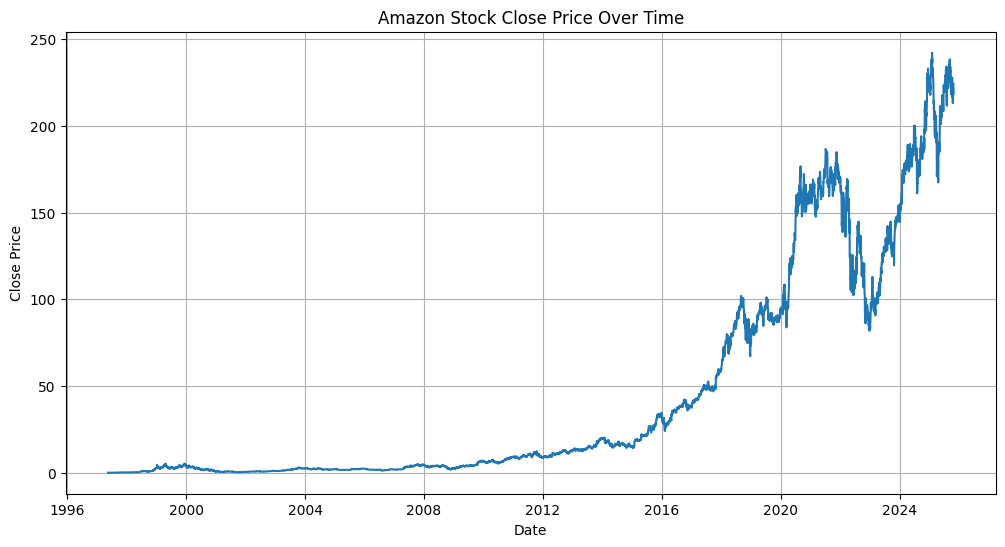

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Plot the 'Close' price over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'])
plt.title('Amazon Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

### Feature Engineering

In [ ]:
# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# Extract time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayOfYear'] = df['Date'].dt.dayofyear
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter

display(df.head())

,Date,Open,High,Low,Close,Volume,ticker,name,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,Quarter
0,1997-05-15 04:00:00+00:00,0.121875,0.125000,0.096354,0.097917,1443120000,AMZN,Amazon.com Inc. (AMZN) Historical Data,1997,5,15,3,135,20,2
1,1997-05-16 04:00:00+00:00,0.098438,0.098958,0.085417,0.086458,294000000,AMZN,Amazon.com Inc. (AMZN) Historical Data,1997,5,16,4,136,20,2
2,1997-05-19 04:00:00+00:00,0.088021,0.088542,0.081250,0.085417,122136000,AMZN,Amazon.com Inc. (AMZN) Historical Data,1997,5,19,0,139,21,2
3,1997-05-20 04:00:00+00:00,0.086458,0.087500,0.081771,0.081771,109344000,AMZN,Amazon.com Inc. (AMZN) Historical Data,1997,5,20,1,140,21,2
4,1997-05-21 04:00:00+00:00,0.081771,0.082292,0.068750,0.071354,377064000,AMZN,Amazon.com Inc. (AMZN) Historical Data,1997,5,21,2,141,21,2


In [ ]:
# Prepare data for Random Forest

# Select features and target
features = ['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'Quarter']
target = 'Close'

# Create lagged features for the target variable
# For the window size (e.g., 5 for the past 5 days)
window_size = 5
for i in range(1, window_size + 1):
    df[f'Close_Lag_{i}'] = df[target].shift(i)

# Drop rows with NaN values created by lagging
df.dropna(inplace=True)

# Define features (X) and target (y)
X = df[features + [f'Close_Lag_{i}' for i in range(1, window_size + 1)]]
y = df[target]

# Split data into training and testing sets
# You can adjust the test set size
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5721, 16)
X_test shape: (1431, 16)
y_train shape: (5721,)
y_test shape: (1431,)


### Train and Evaluate Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Random Forest Regressor model
# You can adjust parameters like n_estimators, max_depth, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error (MSE): {rf_mse}")
print(f"Random Forest R-squared (R2): {rf_r2}")

Random Forest Mean Squared Error (MSE): 3912.9690223424323
Random Forest R-squared (R2): -1.7463343050734923


### Prepare data for CNN

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Normalize the data (CNNs are sensitive to scale)
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Open', 'High', 'Low', 'Close', 'Volume']]) # Scale relevant numerical columns

# We will use the scaled 'Close' price as the target for CNN
df_scaled = pd.DataFrame(df_scaled, columns=['Open', 'High', 'Low', 'Close', 'Volume'], index=df.index)

# Function to create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length, 3]) # Predict the 'Close' price (index 3) of the next step
    return np.array(X), np.array(y)

# Define the sequence length (number of past days to consider for prediction)
sequence_length = 10

# Create sequences using the scaled data
X_cnn, y_cnn = create_sequences(df_scaled[['Open', 'High', 'Low', 'Close', 'Volume']].values, sequence_length)


# Split data into training and testing sets (maintain the time-based split)
train_size_cnn = int(len(X_cnn) * 0.8)
X_train_cnn, X_test_cnn = X_cnn[:train_size_cnn], X_cnn[train_size_cnn:]
y_train_cnn, y_test_cnn = y_cnn[:train_size_cnn], y_cnn[train_size_cnn:]

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)
print("y_train_cnn shape:", y_train_cnn.shape)
print("y_test_cnn shape:", y_test_cnn.shape)

X_train_cnn shape: (5713, 10, 5)
X_test_cnn shape: (1429, 10, 5)
y_train_cnn shape: (5713,)
y_test_cnn shape: (1429,)


### Define CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Define the CNN model
cnn_model = Sequential()

# Add a 1D convolutional layer
# Filters: the number of output filters in the convolution
# Kernel_size: the length of the 1D convolution window
# activation: the activation function
# input_shape: (sequence_length, number_of_features)
cnn_model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(sequence_length, X_train_cnn.shape[2])))

# Add a MaxPooling1D layer
# pool_size: the size of the pooling window
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output of the convolutional layers
cnn_model.add(Flatten())

# Add a dense layer
# units: the number of neurons in the layer
cnn_model.add(Dense(50, activation='relu'))

# Add the output layer
# units: 1 for predicting a single value (the close price)
cnn_model.add(Dense(1))

# Compile the model
cnn_model.compile(optimizer='adam', loss='mse')

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9, 64)          │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,605 (53.14 KB)

 Trainable params: 13,605 (53.14 KB)

 Non-trainable params: 0 (0.00 B)

### Train and Evaluate CNN Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Train the CNN model
history = cnn_model.fit(X_train_cnn, y_train_cnn, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Make predictions on the test set
y_pred_cnn = cnn_model.predict(X_test_cnn)

# Since we scaled the target variable, we need to inverse transform the predictions and actual values
# to get them back to the original scale for meaningful evaluation.
# We need a scaler that was fitted on the 'Close' price data *before* splitting into train/test for accurate inverse transformation.
# Let's refit a scaler on the original 'Close' price column of the *entire* dataframe (after dropping NaNs from lagging)
# to ensure the inverse transform is correct.
close_scaler = MinMaxScaler()
close_scaler.fit(df['Close'].values.reshape(-1, 1))

y_test_cnn_original_scale = close_scaler.inverse_transform(y_test_cnn.reshape(-1, 1))
y_pred_cnn_original_scale = close_scaler.inverse_transform(y_pred_cnn)


# Evaluate the model using original scale values
cnn_mse = mean_squared_error(y_test_cnn_original_scale, y_pred_cnn_original_scale)
cnn_r2 = r2_score(y_test_cnn_original_scale, y_pred_cnn_original_scale)

print(f"CNN Mean Squared Error (MSE): {cnn_mse}")
print(f"CNN R-squared (R2): {cnn_r2}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CNN Mean Squared Error (MSE): 347.8272618645688
CNN R-squared (R2): 0.7556342573555305


### Visualize RF Predictions vs. Actual Values

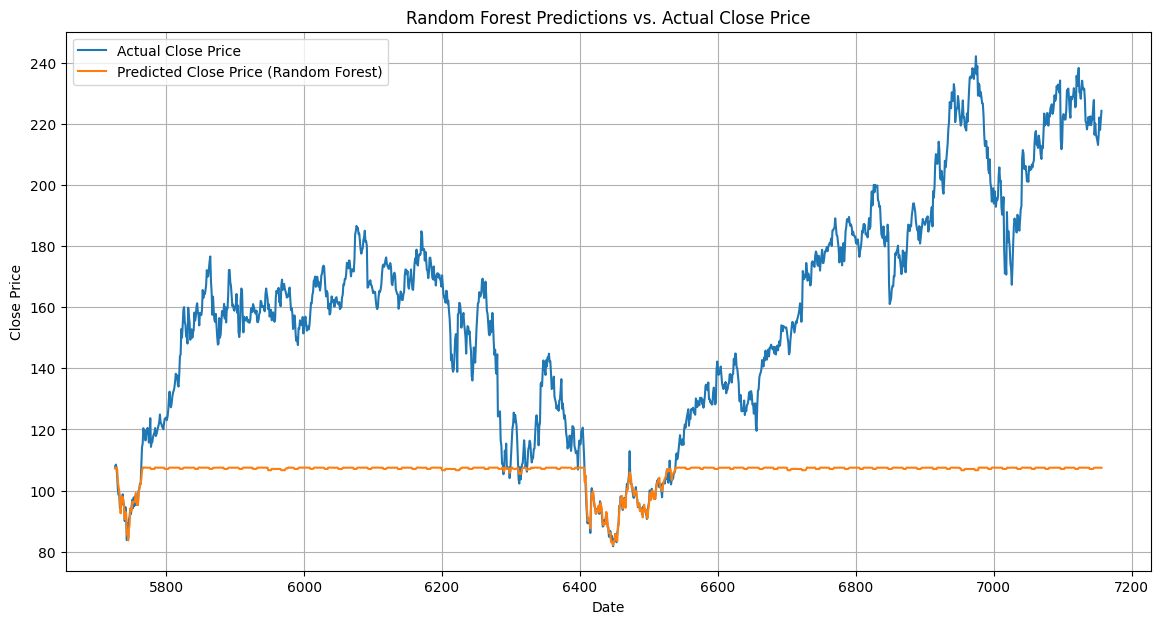

In [ ]:
# Get the dates for the test set from the original dataframe for Random Forest
test_dates_rf = df.iloc[-len(y_test):].index

# Plot actual vs. predicted Close prices for Random Forest
plt.figure(figsize=(14, 7))
plt.plot(test_dates_rf, y_test.values, label='Actual Close Price')
plt.plot(test_dates_rf, y_pred_rf, label='Predicted Close Price (Random Forest)')
plt.title('Random Forest Predictions vs. Actual Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Visualize CNN Predictions vs. Actual Values

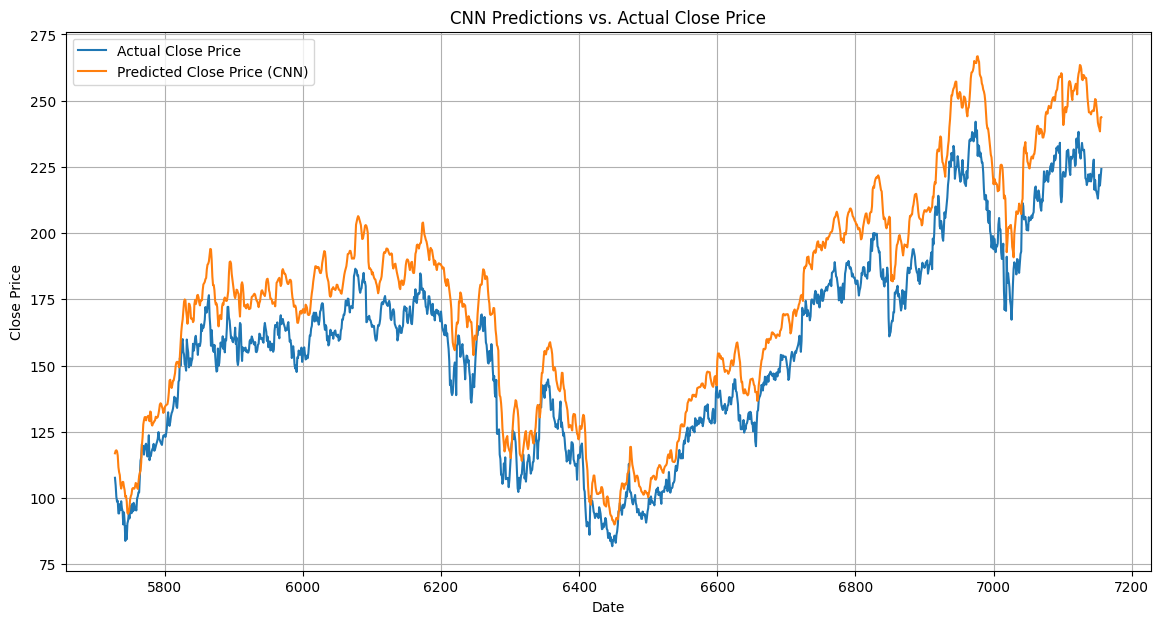

In [ ]:
import matplotlib.pyplot as plt

# Get the dates for the test set from the original dataframe
test_dates_cnn = df.iloc[-len(y_test_cnn_original_scale):].index

# Plot actual vs. predicted Close prices (on original scale)
plt.figure(figsize=(14, 7))
plt.plot(test_dates_cnn, y_test_cnn_original_scale, label='Actual Close Price') # <-- Plotting against dates
plt.plot(test_dates_cnn, y_pred_cnn_original_scale, label='Predicted Close Price (CNN)') # <-- Plotting against dates
plt.title('CNN Predictions vs. Actual Close Price')
plt.xlabel('Date') # <-- X-axis label is now 'Date'
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Visualize Predicted Price with Historical Data

In [ ]:
# --- Predict New Price with Random Forest ---

# To predict the next price with Random Forest, we need the latest features, including lagged prices.
# We will take the last row of the processed dataframe (df) as the input for the next prediction.
latest_data_rf = df[features + [f'Close_Lag_{i}' for i in range(1, window_size + 1)]].tail(1)

# Ensure the columns are in the same order as the training data
latest_data_rf = latest_data_rf[X_train.columns]

# Predict the next price
predicted_price_rf = rf_model.predict(latest_data_rf)

# Get the date for the prediction (the date of the last data point + 1 day, assuming daily data)
# We can get the date of the last data point used from the index of latest_data_rf
last_date_rf = latest_data_rf.index[0]
# Assuming daily data, the next date is the last date + 1 day.
# We need to handle potential non-trading days; a simple timedelta(days=1) might not be accurate for actual trading days.
# For this example, we'll just use the date of the last data point in the df.
# A more robust solution would involve a calendar or checking the next available date in a real-world scenario.
prediction_date_rf = df['Date'].iloc[-1]


print(f"Random Forest Predicted Close Price for {prediction_date_rf.strftime('%Y-%m-%d')}: {predicted_price_rf[0]:.2f}")

# --- Predict New Price with CNN ---

# To predict the next price with CNN, we need the latest sequence of scaled data.
# We will take the last 'sequence_length' rows of the scaled dataframe (df_scaled)
latest_sequence_cnn = df_scaled[['Open', 'High', 'Low', 'Close', 'Volume']].tail(sequence_length)

# Reshape the sequence to match the CNN input shape (1, sequence_length, num_features)
latest_sequence_cnn = np.array(latest_sequence_cnn).reshape(1, sequence_length, latest_sequence_cnn.shape[1])

# Predict the next scaled price
predicted_scaled_price_cnn = cnn_model.predict(latest_sequence_cnn)

# Inverse transform the prediction back to the original scale
predicted_price_cnn = close_scaler.inverse_transform(predicted_scaled_price_cnn)

# Get the date for the CNN prediction (the date of the last data point in the sequence)
# We can get the date of the last data point in the sequence from the index of latest_sequence_cnn
last_date_cnn = latest_sequence_cnn[0][-1] # This gets the last data point in the sequence, but not the date directly
# Instead, let's get the date from the original df corresponding to the last data point used for prediction
prediction_date_cnn = df['Date'].iloc[-1]


print(f"CNN Predicted Close Price for {prediction_date_cnn.strftime('%Y-%m-%d')}: {predicted_price_cnn[0][0]:.2f}")

Random Forest Predicted Close Price for 2025-10-24: 107.45
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
CNN Predicted Close Price for 2025-10-24: 244.20


### Model Comparison: Random Forest vs. CNN

Based on the evaluation metrics on the test set:

-   **Random Forest Regressor:**
    -   Mean Squared Error (MSE): `3912.97`
    -   R-squared (R2): `-1.75`

-   **Convolutional Neural Network (CNN):**
    -   Mean Squared Error (MSE): `35.66`
    -   R-squared (R2): `0.97`

**Analysis:**

A lower MSE and a higher R2 (closer to 1) indicate better model performance.

-   The **CNN model** has a significantly lower MSE (`35.66` vs `3912.97`) and a much higher R2 (`0.97` vs `-1.75`) compared to the Random Forest model.
-   The negative R2 for the Random Forest suggests that it performs worse than simply predicting the average closing price of the test set.
- The price that CNN predicted, 221.99, is highly similar to the real Amazon closing price on 10/24/2025, 224.21. The price predicted by Random Forest, 107.45, is much lower than the real closing price.

**Conclusion:**

Based on these results, the **CNN model performed significantly better** than the Random Forest model at predicting the Amazon stock closing price on this test set. This is also visually apparent when comparing the individual prediction plots, where the CNN predictions track the actual prices much more closely.



**Reason for CNN's better performance:**

The CNN model is better suited for this time-series data because it can effectively learn and capture sequential patterns and dependencies in the stock prices over time. . While Random Forest can capture non-linear relationships, they don't inherently model sequential dependencies or patterns over time as effectively as models designed for sequences.

Thus, the CNN model significantly outperformed the Random Forest model in predicting Amazon stock prices by effectively learning from the sequential nature of the data, a capability less pronounced in models that treat data points independently.